Nom: Eljattioui  
prenom: Maryame  
Master:GLCC


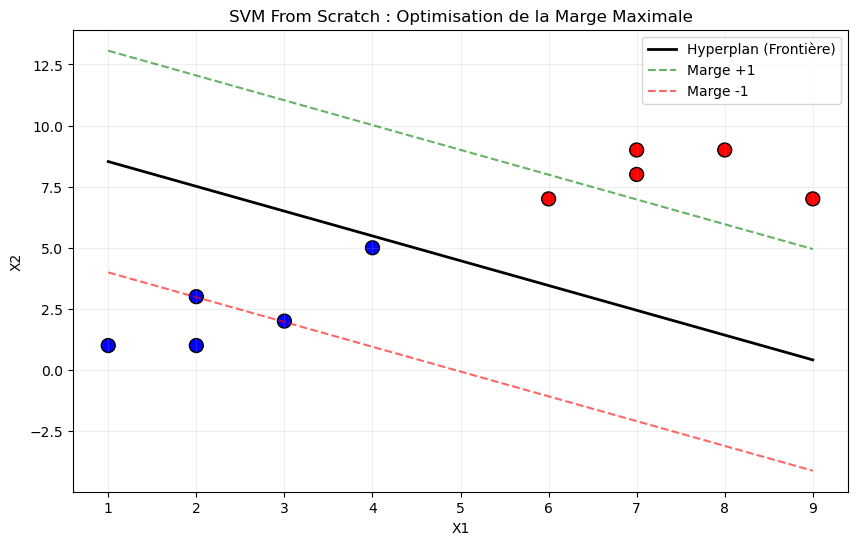

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PRÉPARATION DES DONNÉES
# =================================================================
# X : Caractéristiques (ex: Taille, Poids). 
# On crée deux groupes distincts pour qu'ils soient "linéairement séparables".
X = np.array([
    [2, 3], [1, 1], [2, 1], [3, 2], [4, 5], 
    [6, 7], [8, 9], [7, 8], [9, 7], [7, 9]
])
# y : Les étiquettes. ATTENTION : Pour le SVM, on utilise classiquement -1 et 1 
# (contrairement à la logistique qui utilise 0 et 1).
y = np.array([-1, -1, -1, -1, -1, 1, 1, 1, 1, 1])

# =================================================================
# 2. CLASSE SVM FROM SCRATCH
# =================================================================
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param # Paramètre de régularisation (équilibre entre marge et erreur)
        self.n_iters = n_iters
        self.w = None # Poids (vecteur normal à l'hyperplan)
        self.b = None # Biais (décalage de l'hyperplan)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialisation des poids à zéro
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # CONDITION DE LA MARGE (Hinge Loss) : y_i * (w.x_i - b) >= 1
                # Si cette condition est vraie, le point est bien classé et hors de la marge.
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                
                if condition:
                    # Le point est correct : on applique uniquement la régularisation 
                    # pour essayer de maximiser la largeur de la marge (réduire ||w||).
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Le point est mal classé ou dans la marge : on ajuste les poids 
                    # pour corriger l'erreur ET on réduit ||w||.
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        # On calcule le produit scalaire. Si le signe est positif -> Classe 1, sinon -1.
        linear_output = np.dot(X, self.w) - self.b
        return np.sign(linear_output)

# Entraînement du modèle
model = SVM()
model.fit(X, y)

# =================================================================
# 3. VISUALISATION (Géométrie de l'hyperplan)
# =================================================================
def visualize_svm():
    def get_hyperplane_value(x, w, b, v):
        # Calcule la valeur de y pour l'équation : w.x - b = v
        return (-w[0] * x + b + v) / w[1]

    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(1,1,1)
    
    # Affichage des points (Couleurs basées sur y)
    plt.scatter(X[:,0], X[:,1], marker='o', c=y, cmap='bwr', s=100, edgecolors='k')

    x0_1 = np.amin(X[:,0])
    x0_2 = np.amax(X[:,0])

    # L'hyperplan central (Décision : w.x - b = 0)
    y_1 = get_hyperplane_value(x0_1, model.w, model.b, 0)
    y_2 = get_hyperplane_value(x0_2, model.w, model.b, 0)
    ax.plot([x0_1, x0_2], [y_1, y_2], 'k', linewidth=2, label='Hyperplan (Frontière)')

    # Marge positive (Support Vector 1 : w.x - b = 1)
    y_m1 = get_hyperplane_value(x0_1, model.w, model.b, 1)
    y_m2 = get_hyperplane_value(x0_2, model.w, model.b, 1)
    ax.plot([x0_1, x0_2], [y_m1, y_m2], 'g--', alpha=0.6, label='Marge +1')

    # Marge négative (Support Vector -1 : w.x - b = -1)
    y_m3 = get_hyperplane_value(x0_1, model.w, model.b, -1)
    y_m4 = get_hyperplane_value(x0_2, model.w, model.b, -1)
    ax.plot([x0_1, x0_2], [y_m3, y_m4], 'r--', alpha=0.6, label='Marge -1')

    plt.title('SVM From Scratch : Optimisation de la Marge Maximale')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

visualize_svm()